In [2]:
import tensorflow as tf
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
 

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from matplotlib import pyplot
from sklearn.model_selection import train_test_split
import pandas as pd
import os
from distutils.dir_util import copy_tree, remove_tree

from PIL import Image
from random import randint


 
from sklearn.metrics import matthews_corrcoef as MCC
from sklearn.metrics import balanced_accuracy_score as BAS
from sklearn.metrics import classification_report, confusion_matrix

# import tensorflow_addons as tfa
from keras.layers import LeakyReLU
# from keras.utils.vis_utils import plot_model
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import Conv2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator as IDG
from tensorflow.keras.layers import SeparableConv2D, BatchNormalization, MaxPool2D

In [3]:
# pip list

In [4]:
WORK_DIR = r'C:\Users\user\Downloads\4_project\Malnutrition detection using deep learning\model\dataset\dataset'

CLASSES = ['Malnutrition','Nutrition']

IMG=224

IMAGE_SIZE = [224, 224]
DIM = (IMG,IMG )

In [5]:
ZOOM = [.99, 1.01]
BRIGHT_RANGE = [0.8, 1.2]
HORZ_FLIP = True
FILL_MODE = "constant"
DATA_FORMAT = "channels_last"

work_dr = IDG(rescale = 1./255, brightness_range=BRIGHT_RANGE, zoom_range=ZOOM, data_format=DATA_FORMAT, fill_mode=FILL_MODE, horizontal_flip=HORZ_FLIP)

train_data_gen = work_dr.flow_from_directory(directory=WORK_DIR, target_size=DIM, batch_size=2009 , shuffle=False)

Found 2009 images belonging to 2 classes.


In [6]:
train_data, train_labels = train_data_gen.__next__()

In [7]:
print(train_data.shape, train_labels.shape)

(2009, 224, 224, 3) (2009, 2)


In [8]:
# train_data, test_data, train_labels, test_labels = train_test_split(train_data, train_labels, test_size = 0.1, random_state=42)
train_data, val_data, train_labels, val_labels = train_test_split(train_data, train_labels, test_size = 0.2, random_state=42)

In [9]:
print(train_data.shape)

(1607, 224, 224, 3)


In [10]:
import warnings
 

import os
import glob
import matplotlib.pyplot as plt

# Import Keras
import keras
from keras.models import Sequential
from keras.layers import Dense,Dropout,Flatten
from keras.layers import Conv2D,MaxPooling2D,Activation,AveragePooling2D,BatchNormalization
# from keras.preprocessing.image import ImageDataGenerator

In [11]:
# s=224
# from tensorflow.keras.applications import DenseNet121,MobileNet,ResNet50
# from tensorflow.keras.utils import plot_model
# pre_trained_model = ResNet50(input_shape = (s, s, 3), 
#                                 include_top = False, 
#                                 weights = 'imagenet')
# for layer in pre_trained_model.layers:
#     layer.trainable = False  #to make the layers to Freeze Weights
# #pre_trained_model.summary()
#plot_model(pre_trained_model, show_shapes=True, to_file='InceptionV3.png')

In [12]:
from tensorflow.keras.applications.mobilenet import MobileNet
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import Sequential
from tensorflow.keras.applications import DenseNet121,MobileNet,ResNet50,DenseNet201
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications import ResNet152V2
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications import MobileNetV2


In [13]:
base_model = ResNet152V2(weights = 'imagenet', include_top=False, input_shape=(224, 224, 3))


234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 1913s 8us/step


In [14]:
base_model.trainable = False

In [15]:
base_model.summary()

Model: "resnet152v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 58,331,648 (222.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 58,331,648 (222.52 MB)

In [16]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, GlobalAveragePooling2D


In [17]:
model = tf.keras.models.Sequential()

model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(2, activation = 'softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet152v2 (Functional)        │ (None, 7, 7, 2048)     │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,335,746 (222.53 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 58,331,648 (222.52 MB)

In [18]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping,ReduceLROnPlateau
from tensorflow.keras import layers, optimizers, losses, metrics, callbacks, initializers

In [19]:
# checkpoint = callbacks.ModelCheckpoint(
#     # filepath='MobileNet.keras',
#     monitor='val_accuracy',
#     verbose=1,
#     save_best_only=True,
#     mode = 'max')

In [20]:
# model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')

In [21]:
# callbacks1=[model_chkpt]

In [22]:
model.compile(optimizer= 'adam' , loss= 'categorical_crossentropy', metrics=['accuracy'])

In [23]:
history = model.fit(train_data, train_labels, validation_data=(val_data, val_labels), epochs=10)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.8449 - loss: 0.3373 - val_accuracy: 0.9353 - val_loss: 0.1520
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.9616 - loss: 0.1021 - val_accuracy: 0.9453 - val_loss: 0.1236
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.9772 - loss: 0.0760 - val_accuracy: 0.9353 - val_loss: 0.1278
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.9826 - loss: 0.0474 - val_accuracy: 0.9428 - val_loss: 0.1201
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.9943 - loss: 0.0362 - val_accuracy: 0.9527 - val_loss: 0.1162
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.9929 - loss: 0.0373 - val_accuracy: 0.9502 - val_loss: 0.1165
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.9973 - loss: 0.0274 - val_accuracy: 0.9502 - val_loss: 0.1212
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.9937 - loss: 0.0298 - val_accuracy: 0.9502 - v

In [24]:
model.save("ResNet152V2.h5")

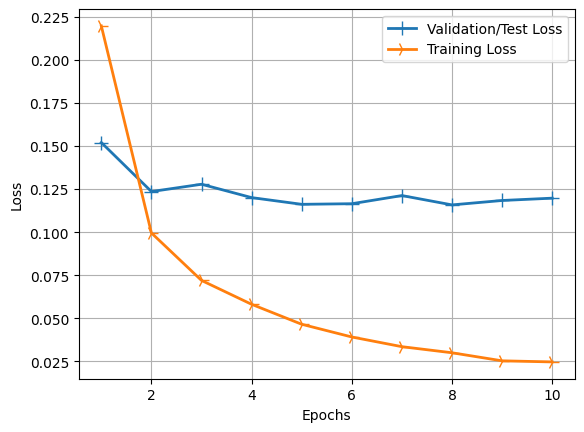

In [25]:
history_dict = history.history

loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

line1 = plt.plot(epochs, val_loss_values, label='Validation/Test Loss')
line2 = plt.plot(epochs, loss_values, label='Training Loss')
plt.setp(line1, linewidth=2.0, marker = '+', markersize=10.0)
plt.setp(line2, linewidth=2.0, marker = '4', markersize=10.0)
plt.xlabel('Epochs') 
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

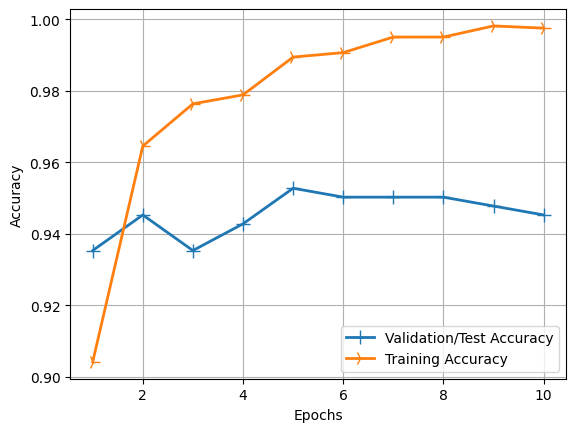

In [26]:
history_dict = history.history

acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(loss_values) + 1)

line1 = plt.plot(epochs, val_acc_values, label='Validation/Test Accuracy')
line2 = plt.plot(epochs, acc_values, label='Training Accuracy')
plt.setp(line1, linewidth=2.0, marker = '+', markersize=10.0)
plt.setp(line2, linewidth=2.0, marker = '4', markersize=10.0)
plt.xlabel('Epochs') 
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

In [27]:
import numpy as np

In [28]:
pred_labels = model.predict(val_data)
#Print the classification report of the tested data

#Since the labels are softmax arrays, we need to roundoff to have it in the form of 0s and 1s,
#similar to the test_labels
def roundoff(arr):
    """To round off according to the argmax of each predicted label array. """
    arr[np.argwhere(arr != arr.max())] = 0
    arr[np.argwhere(arr == arr.max())] = 1
    return arr

for labels in pred_labels:
    labels = roundoff(labels)
print(classification_report(val_labels, pred_labels, target_names=CLASSES))

13/13 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step
              precision    recall  f1-score   support

Malnutrition       0.95      0.94      0.94       198
   Nutrition       0.94      0.95      0.95       204

   micro avg       0.95      0.95      0.95       402
   macro avg       0.95      0.95      0.95       402
weighted avg       0.95      0.95      0.95       402
 samples avg       0.95      0.95      0.95       402



In [29]:
import seaborn as sns

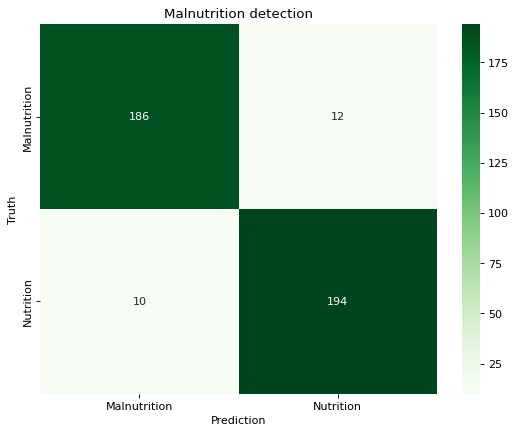

In [30]:

pred_ls = np.argmax(pred_labels, axis=1)
test_ls = np.argmax(val_labels, axis=1)

conf_arr = confusion_matrix(test_ls, pred_ls)

plt.figure(figsize=(8, 6), dpi=80, facecolor='w', edgecolor='k')

ax = sns.heatmap(conf_arr, cmap='Greens', annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES)

plt.title('Malnutrition detection')
plt.xlabel('Prediction')
plt.ylabel('Truth')
plt.show(ax)